# Baseline Forecast: Item 1 Demand
Building a naive baseline and a first Prophet model, and comparing them on held-out MAE/MAPE.

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv('/train.csv', parse_dates=['date'])
test = pd.read_csv('/test.csv', parse_dates=['date'])
sample_submission = pd.read_csv('/sample_submission.csv')

print("Data loaded successfully!")
train.head()

Data loaded successfully!


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [2]:
item_1 = train[train['item'] == 1].groupby('date')['sales'].sum().reset_index()
df = item_1
df['dayofweek'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['lag_7'] = df['sales'].shift(7)
df['rolling_mean_7'] = df['sales'].shift(1).rolling(7).mean()
df.head(10)

,date,sales,dayofweek,month,lag_7,rolling_mean_7
0,2013-01-01,133,1,1,NaN,NaN
1,2013-01-02,99,2,1,NaN,NaN
2,2013-01-03,127,3,1,NaN,NaN
3,2013-01-04,145,4,1,NaN,NaN
4,2013-01-05,149,5,1,NaN,NaN
5,2013-01-06,149,6,1,NaN,NaN
6,2013-01-07,92,0,1,NaN,NaN
7,2013-01-08,119,1,1,133.0,127.714286
8,2013-01-09,114,2,1,99.0,125.714286
9,2013-01-10,103,3,1,127.0,127.857143


In [3]:
df['naive_forecast'] = df['sales'].shift(7)  # "same as this day last week"

def mae(actual, pred):
    return np.mean(np.abs(actual - pred))
def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

valid = df.dropna(subset=['naive_forecast'])
naive_mae = mae(valid['sales'], valid['naive_forecast'])
naive_mape = mape(valid['sales'], valid['naive_forecast'])
print('Naive MAE:', naive_mae)
print('Naive MAPE:', naive_mape)

Naive MAE: 19.034084661902146
Naive MAPE: 9.0714084197783


Importing plotly failed. Interactive plots will not work.


06:27:43 - cmdstanpy - INFO - Chain [1] start processing


06:27:43 - cmdstanpy - INFO - Chain [1] done processing


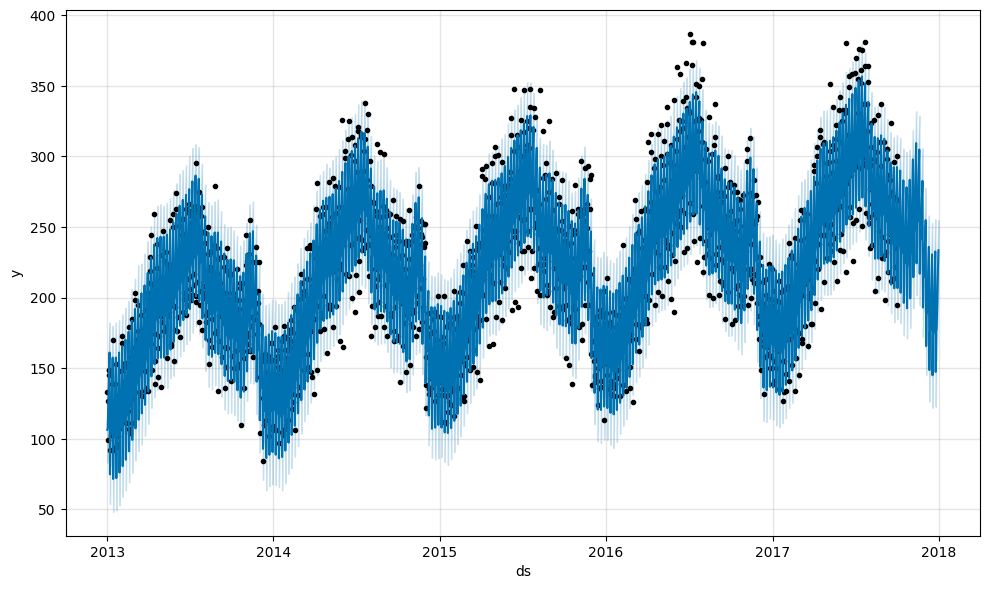

In [4]:
from prophet import Prophet

prophet_df = df[['date','sales']].rename(columns={'date':'ds', 'sales':'y'})

# time-based split — never shuffle time series data randomly
test_days = 90
train_df = prophet_df.iloc[:-test_days]
test_df = prophet_df.iloc[-test_days:]

m = Prophet()
m.fit(train_df)
future = m.make_future_dataframe(periods=test_days)
forecast = m.predict(future)
fig = m.plot(forecast)
fig.savefig('baseline_prophet_plot.png', dpi=100)

In [5]:
pred = forecast.set_index('ds').loc[test_df['ds'], 'yhat'].values
actual = test_df['y'].values
prophet_mae = mae(actual, pred)
prophet_mape = mape(actual, pred)
print('Prophet MAE:', prophet_mae)
print('Prophet MAPE:', prophet_mape)

Prophet MAE: 14.421617569648273
Prophet MAPE: 6.639052270074325


## Baseline result
The default Prophet model already beats the naive "same day last week" baseline on both MAE and MAPE (see printed values above). Next notebook tunes Prophet's seasonality settings and tests SARIMA as an alternative, to see if either improves further before locking in a final model for the inventory recommendation.